# The whole loop, once

Vendor files to a decision, with nothing skipped: ingest, pin, build a
strategy from the pack, search it walk-forward with the holdout spent on a
shortlist, compare the runs in one report, and check the winner survives the
size of the search. Recipe 05/06 covers the ingest step in detail; this one
runs it in three lines and spends its length on what comes after.

The order matters more than any individual step. Every h5i-db feature used
here exists to keep one property true: the number at the end is attributable
to a pinned input, a named strategy, and a search whose shape is on the record.

## Terms used here

| term            | meaning |
| --------------- | --- |
| strategy pack   | a set of parameterized rules the search enumerates, rather than hand-written variants |
| walk-forward    | repeatedly fit on a window and test on the window after it, rolling forward |
| shortlist       | the few candidates the holdout is spent on, chosen without seeing it |
| holdout         | data deliberately untouched until the end, which can only be spent once |
| basket report   | one comparison table across all runs, so the choice is made in one place |
| Brier advantage | how much a forecast beats the base rate, in Brier score terms |
| deflated Sharpe | a Sharpe adjusted downward for how many variants were tried |
| pin             | fixing a run's inputs to an exact snapshot, so the final number is attributable |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

db = h5i_db.Database(cu.fresh_db("05_end_to_end_workflow"), create=True)
FEE_RATE = 0.07

## 1. Ingest, and pin what you ingested

The mirror stands in for a real one. `write_markets` writes `instruments` and
`resolutions`; `ingest_archive` writes `book_deltas` and `trades`. The snapshot
is the step that makes everything afterwards reproducible: from here on, every
read names `mirror-v1` rather than "whatever the table holds".

In [2]:
panel_tables = cu.make_prediction_markets(n_markets=60, steps=32, seed=11)
mirror = Path("data/cache/e2e-mirror")
files = cu.write_polymarket_archive(panel_tables, mirror)
specs = venues.polymarket_markets_from_json(cu.polymarket_market_payloads(panel_tables))

venues.write_markets(db, specs, note="market definitions")
ingest = venues.ingest_archive(
    db, files=files, markets=specs, layout=venues.PMXT_LAYOUT, note="backfill"
)
db.snapshot("mirror-v1", tables=list(venues.CANONICAL_SCHEMAS), note="study input")
print(f"{len(files)} files -> {ingest.rows:,} rows across {len(ingest.tables)} tables")
print(f"gaps: {len(ingest.gaps)}, unrecognised events: {len(ingest.skipped)}")
print({name: write.rows for name, write in sorted(ingest.tables.items())})

10 files -> 10,560 rows across 2 tables
gaps: 0, unrecognised events: 0
{'book_deltas': 8640, 'trades': 1920}


## 2. The quote panel

One row per market per instant, which is what every strategy in the pack
consumes. `quote_panel` stops at `expiration_ns` on purpose: the data keeps
quoting after resolution, and a momentum rule reading that jump to 0 or 1 would
find a signal that is really an answer.

| column | type | meaning |
|---|---|---|
| `ts` | `timestamp[ns]` | the quote instant |
| `instrument_id` | `string` | the market |
| `bid`, `ask` | `float64` | best prices, as probabilities |
| `bid_size`, `ask_size` | `float64` | displayed depth |

In [3]:
panel = backtest.quote_panel(db, snapshot="mirror-v1")
print(f"{len(panel):,} rows x {len(panel.columns)} columns")
print(f"{panel.instrument_id.nunique()} markets, {panel.ts.nunique()} instants")
expiry = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
print(f"panel ends {panel.ts.max()}, expiry {pd.Timestamp(expiry, unit='ns')}")
panel.head()

1,920 rows x 6 columns
60 markets, 32 instants
panel ends 2026-05-01 19:45:00, expiry 2026-05-01 19:45:00


,instrument_id,ts,bid,ask,bid_size,ask_size
0,EVENT-0000,2026-05-01 12:00:00,0.087,0.103,89.826,61.859
1,EVENT-0000,2026-05-01 12:15:00,0.084,0.100,74.195,68.905
2,EVENT-0000,2026-05-01 12:30:00,0.082,0.098,62.506,77.972
3,EVENT-0000,2026-05-01 12:45:00,0.084,0.100,56.045,88.614
4,EVENT-0000,2026-05-01 13:00:00,0.081,0.097,55.524,100.308


## 3. Pick a strategy from the pack

The pack ships the standard rules as signal *generators*: each returns a table,
never a callback object. That is what lets the trial ledger identify a strategy
by content and `verify()` reproduce it later. A callback can do more, and pays
for it with no content identity.

In [4]:
print("available:", ", ".join(sorted(backtest.STRATEGIES)))
counts = {}
for name, generator in sorted(backtest.STRATEGIES.items()):
    counts[name] = generator(panel).num_signals
print("\nsignals each rule produces on this panel:")
for name, count in sorted(counts.items(), key=lambda item: -item[1]):
    print(f"  {name:24} {count:>5}")

available: breakout, deep_value, ema_crossover, final_period_momentum, late_favorite_hold, mean_reversion, microprice_imbalance, panic_fade, rsi_reversion, threshold_momentum, vwap_reversion



signals each rule produces on this panel:
  rsi_reversion              244
  ema_crossover              172
  microprice_imbalance        81
  threshold_momentum          81
  mean_reversion              48
  breakout                    17
  late_favorite_hold          12
  vwap_reversion              11
  deep_value                   5
  final_period_momentum        1
  panic_fade                   0


`ema_crossover` is the choice here, and the reason is the search that follows
rather than the rule itself. A walk-forward splits on *time*, so every fold
needs trades inside it; a hold-to-resolution rule like `late_favorite_hold`
trades once per market and would leave most folds empty, which is exactly the
vacuous split recipe 05/05 warns about. Rules that trade throughout a session
are the ones a time split can score.

The plan carries its parameters, so a run's metadata cannot drift away from the
signals it actually replayed.

In [5]:
plan = backtest.strategies.ema_crossover(
    panel, fast=4, slow=12, quantity=20.0, long_only=True
)
print(f"strategy   {plan.strategy}")
print(f"parameters {plan.parameters}")
print(f"signals    {plan.num_signals}")
db.create_table("signals", plan.signals.schema, time_column="ts")
db.append("signals", plan.signals, note=f"{plan.strategy} {plan.parameters}")
plan.signals.to_pandas().head(3)

strategy   ema_crossover
parameters {'fast': 4, 'slow': 12, 'quantity': 20.0}
signals    271


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-05-01 12:15:00.000001024,EVENT-0001,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False
1,2026-05-01 12:15:00.000001024,EVENT-0004,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False
2,2026-05-01 12:15:00.000001024,EVENT-0005,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False


## 4. Preflight, before spending anything

`inspect` reports the fidelity the data supports and refuses claims it does
not. Asking for queue-position fills from periodic snapshots is an error here,
not a plausible-looking number later.

In [6]:
def config(
    run_id: str, *, fee_rate_override: float | None = None, **execution
) -> backtest.BacktestConfig:
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(signals="signals", snapshot="mirror-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=250_000.0),
        execution=backtest.ExecutionConfig(
            fee_kind="kalshi",
            fee_rate=FEE_RATE if fee_rate_override is None else fee_rate_override,
            **execution,
        ),
        output=backtest.OutputConfig(equity_interval_nanos=15 * 60 * 1_000_000_000),
        metadata=plan.to_metadata(),
    )


accepted = backtest.inspect(db, config("preflight"))
print(f"fidelity {accepted.fidelity}, accepted {accepted.ok}")
for issue in accepted.warnings:
    print(f"  warning {issue.code}: {issue.message}")
try:
    backtest.inspect(db, config("queue", queue_position=True)).raise_for_errors()
except ValueError as error:
    print(f"\nqueue claim refused: {str(error).splitlines()[0]}")

fidelity ReplayFidelity.SNAPSHOT_L2, accepted True
  warning snapshot_only: periodic snapshots cannot reconstruct queue transitions between events



queue claim refused: backtest preflight failed: unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs


## 5. Search it walk-forward, holdout on a shortlist

Three folds instead of one train/holdout pair, because a candidate that wins
one window and loses two is not a finding. `TopK` then makes the holdout a
second stage: candidates are ranked on train, only the best few run out of
sample, and nothing else ever touches it. A holdout every candidate touched is
a second training set with a different name.

The ranking metric is `realized_pnl`, not `final_cash`. A fold window ends
mid-session, so a rule holding a position at the boundary has spent cash it has
not yet recovered, and `final_cash` would rank candidates by how much capital
they happened to have deployed when the clock ran out. Pick a metric that is
closed at the window edge.

In [7]:
stamps = list(
    db.sql("SELECT DISTINCT ts_init FROM book_deltas ORDER BY ts_init").to_pandas().ts_init
)
edges = [0, 8, 12, 16, 20, 24, 28]
walk = backtest.WalkForward.of(
    *[
        backtest.ValidationWindows(
            train=(stamps[edges[index]], stamps[edges[index + 1]]),
            holdout=(stamps[edges[index + 1]], stamps[edges[index + 2]]),
        )
        for index in range(0, len(edges) - 2, 2)
    ]
)
for index, fold in enumerate(walk.folds):
    print(f"fold {index}: train {fold.train[0].time()}-{fold.train[1].time()} "
          f"holdout {fold.holdout[0].time()}-{fold.holdout[1].time()} "
          f"embargo {fold.embargo_ns / 1e9:.0f}s")

fold 0: train 12:00:00-14:00:00 holdout 14:00:00-15:00:00 embargo 0s
fold 1: train 15:00:00-16:00:00 holdout 16:00:00-17:00:00 embargo 0s
fold 2: train 17:00:00-18:00:00 holdout 18:00:00-19:00:00 embargo 0s


In [8]:
study = backtest.study(
    db,
    study_id="e2e-fees",
    base=config("e2e-fees"),
    parameters={"execution.fee_rate": [0.0, 0.02, 0.04, FEE_RATE]},
    validation=walk,
    selection=backtest.TopK(k=2, metric="realized_pnl"),
)
board = pd.DataFrame(study.ranked())
columns = ["trial", "parameters", "train_median_realized_pnl", "holdout_median_realized_pnl"]
print(board[columns].to_string(index=False))
print(f"\ntrials run: {len(study.trials)}, reached the holdout: {len(study.selected)}")
print(f"attention: {study.attention_state}, unseen warnings: {study.warning_badge}")

 trial                   parameters  train_median_realized_pnl  holdout_median_realized_pnl
     0  {"execution.fee_rate": 0.0}                      -0.92                        -0.80
     1 {"execution.fee_rate": 0.02}                      -2.12                        -1.74

trials run: 4, reached the holdout: 2
attention: AttentionState.FAILED_WARNED, unseen warnings: 4


Only the shortlist has holdout columns at all. That is the property worth
checking in your own studies: if every candidate has an out-of-sample score,
the out-of-sample set is not one.

In [9]:
for row in sorted(study.trials, key=lambda item: item["trial"]):
    has_holdout = any(key.startswith("fold0_holdout_") for key in row)
    print(f"trial {row['trial']}  selected={row['selected']!s:5} "
          f"holdout_columns={has_holdout}")

trial 0  selected=True  holdout_columns=True
trial 1  selected=True  holdout_columns=True
trial 2  selected=False holdout_columns=False
trial 3  selected=False holdout_columns=False


## 5b. What the sweep is actually worth

A fee sweep has a known direction: lower is always better, so the ranking is
not the finding. The useful number is the crossover, the fee this edge can
absorb before it stops being one. Every candidate has a train score, so that
reads straight off the study even for the trials the holdout never saw.

Note what a study cannot vary: `data.signals` is a data-identity field, so
searching a *strategy* parameter means one signals table per candidate and one
run each, the way recipe 05/05 does it. A study varies execution, portfolio,
risk and output.

In [10]:
absorbed = []
for row in sorted(study.trials, key=lambda item: item["trial"]):
    if row["status"] != "ok":
        continue
    rate = json.loads(row["parameters"])["execution.fee_rate"]
    train = row["train_median_realized_pnl"]
    absorbed.append(
        {
            "fee_rate": rate,
            "train_median_realized_pnl": train,
            "profitable": train > 0.0,
            "reached_holdout": row["selected"],
        }
    )
frame = pd.DataFrame(absorbed)
print(frame.to_string(index=False))
survivors = frame[frame.profitable]
if len(survivors) and len(survivors) < len(frame):
    print(f"\nthe edge survives up to a {survivors.fee_rate.max():.2%} fee and "
          f"not at {frame[~frame.profitable].fee_rate.min():.2%}")
else:
    print("\nno crossover inside the swept range: widen it before concluding")

 fee_rate  train_median_realized_pnl  profitable  reached_holdout
     0.00                      -0.92       False             True
     0.02                      -2.12       False             True
     0.04                      -3.24       False            False
     0.07                      -4.92       False            False

no crossover inside the swept range: widen it before concluding


## 6. Run the winner, and account for it properly

`realized_pnl` covers closed trades only. These positions are held to
resolution, so the result lives in `bt_positions.settlement_pnl`, and the
settlement only applies because the replay reached past the observability
instant. Both numbers survive, so the part of the result that depends on
holding is an explicit figure rather than an assumption.

In [11]:
winner = study.ranked()[0]
best_fee = float(json.loads(winner["parameters"])["execution.fee_rate"])
final = backtest.execute(db, config("e2e-final", fee_rate_override=best_fee))
positions = final.positions.to_pandas()
summary = final.summary()
settled = float(positions.settlement_pnl.fillna(0.0).sum())
marked = float(positions.market_exit_pnl.fillna(0.0).sum())
print(f"winning fee_rate on holdout: {best_fee}")
print(f"fills                 {summary['fills']}")
print(f"realized (round trips){summary['realized_pnl']:>12,.2f}")
print(f"marked to last quote  {marked:>12,.2f}")
print(f"settled at resolution {settled:>12,.2f}")
print(f"settlement adjustment {settled - marked:>+12,.2f}")
print(f"fees                  {summary['commissions']:>12,.2f}")
# realized_pnl is already net of commissions, so the total is realized +
# settlement. Subtracting commissions again double-counts them, and settlement
# alone drops every closed round trip.
print(f"net                   {summary['realized_pnl'] + settled:>12,.2f}")
print(f"settlement applied:   {bool(final.run.to_pandas().settlement_applied.iloc[0])}")

winning fee_rate on holdout: 0.0
fills                 271
realized (round trips)      -48.52
marked to last quote         12.29
settled at resolution        12.40
settlement adjustment        +0.11
fees                          0.00
net                         -36.12
settlement applied:   True


Read those two lines together before believing either. `realized_pnl` is what
the rule earned on trades it closed, and it is firmly negative: the crossings
lost money. `settlement_pnl` is what the positions still open at the end turned
into, and it is positive, but nowhere near enough to cover the trading loss.

The total is the sum of the two, and the arithmetic is worth stating because
the intuitive alternative is wrong. `realized_pnl` already carries the
commissions, so subtracting them again double-counts; and settlement on its own
ignores every position the rule opened and closed, which for a crossover rule
is nearly all of them. Only when nothing closes before resolution do the two
spellings agree, which is exactly the case that hides the mistake.

## 7. Was the probability any better than the price?

A comparison an equity curve cannot make. This strategy's implied forecast is
simple: it bought at the ask, so its probability is that ask. The market's own
forecast is the mid. `brier_advantage` scores both against the realized
outcome, and cannot be inflated by sizing.

In [12]:
fills = final.fills.to_pandas()
truth = cu.market_truth(panel_tables).to_pandas().set_index("instrument_id")
mids = panel.groupby("instrument_id").apply(
    lambda group: group.sort_values("ts").iloc[len(group) // 2], include_groups=False
)
scored = pd.DataFrame(
    {
        "strategy": fills.groupby("instrument_id").price.mean(),
        "market": ((mids.bid + mids.ask) / 2),
    }
).dropna()
scored["outcome"] = truth.yes_won.astype(float)
scored = scored.dropna()
advantage = quant.brier_advantage(
    scored.strategy.tolist(), scored.market.tolist(), scored.outcome.tolist()
)
print(f"markets scored     {advantage.observations}")
print(f"strategy Brier     {advantage.strategy_brier:.4f}")
print(f"market   Brier     {advantage.market_brier:.4f}")
print(f"advantage          {advantage.advantage:+.4f}")
print(f"skill score        {advantage.skill_score:+.3f}")
print(f"beat the market on {advantage.win_rate:.0%} of markets")

markets scored     60
strategy Brier     0.1682
market   Brier     0.1688
advantage          +0.0006
skill score        +0.004
beat the market on 50% of markets


## 8. One report over every run

A sweep leaves one fork per trial, and opening them one at a time is not
comparing them. The basket report assembles a single document from the stored
tables, with no re-simulation: portfolio panels first, per-run panels while the
basket is small enough to read, and fill markers on the book the fills actually
met.

In [13]:
runs = {"final": final}
for row in study.selected:
    fork = row.get("fold0_holdout_fork") or row.get("fold0_train_fork")
    if fork:
        runs[f"trial{row['trial']}"] = backtest.open_result(db, fork.removeprefix("bt-"))
report = quant.basket_payload(
    db,
    runs,
    basket_id="late-favorite basket",
    panels=quant.PORTFOLIO_PANELS + ("equity", "price", "allocation"),
    snapshot="mirror-v1",
    brier={
        "final": {
            "strategy": scored.strategy.tolist(),
            "market": scored.market.tolist(),
            "outcome": scored.outcome.tolist(),
        }
    },
)
print(f"runs      {report.totals['runs']}")
print(f"net       {report.totals['net']:,.2f}")
print(f"drawdown  {report.totals.get('max_drawdown', 0):.4f}")
print(f"panels    {', '.join(report.drawn)}")
if report.skipped:
    print(f"not drawn {[item['panel'] for item in report.skipped]}")
path = report.to_html("data/cache/e2e-basket.html")
print(f"\nwrote {len(path):,} bytes of self-contained HTML")

runs      3
net       -38.66
drawdown  -0.0001
panels    total_equity, total_drawdown, total_rolling_sharpe, total_cash_equity, periodic_pnl, leaderboard, equity, price, allocation

wrote 311,768 bytes of self-contained HTML


## 9. Does the winner survive the search that found it?

Four candidates is a small search and this is a small panel, so the honest
expectation is "not decidable yet". Quoting the number of observations still
needed is more useful than quoting a Sharpe.

In [14]:
equity = final.equity.to_pandas().sort_values("ts")
levels = equity.equity.tolist()
returns = [
    (levels[index] - levels[index - 1]) / levels[index - 1]
    for index in range(1, len(levels))
    if levels[index - 1]
]
deflated = quant.deflated_sharpe(returns, trials=len(study.trials))
track = quant.minimum_track_record_length(returns)
print(f"observed Sharpe            {deflated.sharpe:.3f}")
print(f"benchmark after {deflated.trials} trials  {deflated.benchmark:.3f}")
print(f"P(true Sharpe > benchmark) {deflated.probability:.3f}")
if track == float("inf"):
    print("observations needed        no finite length suffices: the observed")
    print("                          Sharpe sits below the deflated benchmark")
else:
    print(f"observations needed        {track:.0f}, available {len(returns)}")
print(f"skew {deflated.skew:+.2f}, excess kurtosis {deflated.kurtosis:.2f}")

observed Sharpe            -0.446
benchmark after 4 trials  0.186
P(true Sharpe > benchmark) 0.029
observations needed        no finite length suffices: the observed
                          Sharpe sits below the deflated benchmark
skew +3.97, excess kurtosis 21.58


A required track record of infinity is not a bug: the observed Sharpe is below
the benchmark the deflation sets for four trials, so no amount of additional
data makes *this* result significant. The honest report is that the search did
not find an edge, which is the common outcome and the one worth being able to
state.

The skew and kurtosis explain the verdict before the Sharpe does: a
hold-to-resolution book is flat and then jumps, so its return distribution is
one outlier surrounded by noise, and Sharpe assumes something much closer to
normal. The bucketed hold-to-resolution returns from recipe 05/03 are the
better estimator for this payoff shape. The deflation is still worth running,
because it says so rather than reporting a comfortable number.

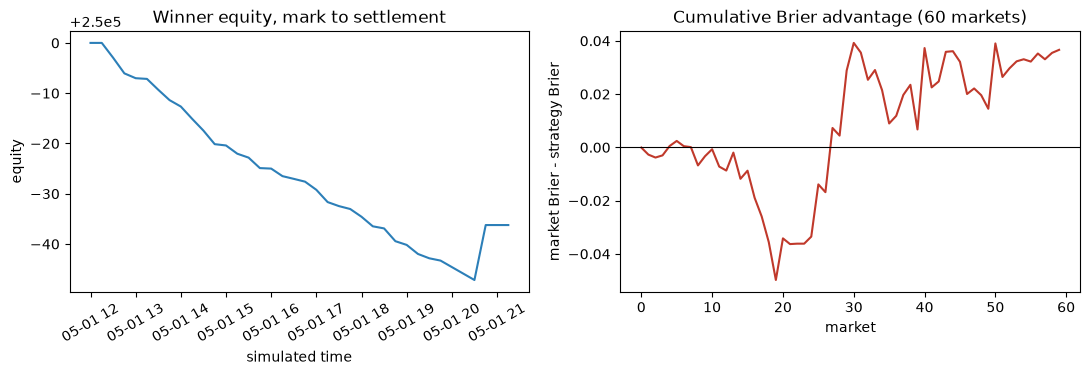

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(equity.ts, equity.equity, color="#2c7fb8")
axes[0].set_title("Winner equity, mark to settlement")
axes[0].set_xlabel("simulated time")
axes[0].set_ylabel("equity")
axes[0].tick_params(axis="x", labelrotation=30)
axes[1].plot(advantage.cumulative, color="#c0392b")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title(f"Cumulative Brier advantage ({advantage.observations} markets)")
axes[1].set_xlabel("market")
axes[1].set_ylabel("market Brier - strategy Brier")
fig.tight_layout()

## 10. Reproduce it from the record

The claim the whole pipeline exists to support. `verify()` re-executes the
stored config into a scratch fork and compares every metric and all four result
tables row for row. Nothing was carried in a variable: the pin, the signals and
the config were all read back from the database.

In [16]:
verified = final.verify()
print(f"verified: {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"all equal: {all(verified['tables_equal'].values())}")
print(f"\nconfig digest {final.config.digest[:16]}")
print(f"trial digest  {final.config.trial_digest[:16]} (excludes run_id and metadata)")
print(f"data pin      {final.config.data.snapshot}")

verified: True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
all equal: True

config digest 036d0028c1501535
trial digest  9dd7b71a6de35f6b (excludes run_id and metadata)
data pin      mirror-v1


## Takeaways

- The loop is: ingest, pin, panel, strategy, preflight, search, account,
  report, deflate, verify. Skipping the pin breaks everything after it, and
  skipping the deflation makes the last number mean less than it looks.
- Walk-forward with `TopK` keeps the holdout a holdout. Check that only the
  shortlist has out-of-sample columns; if everything does, you have two
  training sets.
- The total is `realized_pnl + settlement_pnl`, and nothing else. The first
  already nets out commissions, so subtracting them again double-counts, and
  settlement alone silently drops every position the rule closed. Here trading
  lost more than settlement returned, so the run is a loss; a
  hold-to-resolution rule would make the two spellings agree and hide the
  distinction entirely.
- `market_exit_pnl` beside them says how much of the result depends on holding
  at all, and settlement only applied because the replay reached past the
  observability instant.
- Choose a ranking metric that is closed at the window edge. `final_cash`
  inside a fold ranks candidates by deployed capital, not by performance.
- `brier_advantage` asks whether the forecast beat the price, which no equity
  curve can answer and which sizing cannot inflate.
- h5i-db features doing the work: content-addressed ingest, a named snapshot
  behind every read, one fork per trial so folds cannot contaminate each other,
  `bt_equity` making runs comparable in one report, and `verify()` proving the
  result is reproducible from the record rather than from this session.

In [17]:
db.close()